<h3 align="left"> Практическая работа 2. Загрузка данных и преобразование форматов</h3>


---

<h3 align="left"> Вариант 7,2,1 </h3>

---


<h3 align="left"> Формат No1 => Формат No2: XLSX => JSON </h3>
<h3 align="left"> Преобразование: Удалить записи с нечетным
номером дома </h3>
<h3 align="left"> Закон
распределения для
даты рождения: Равномерное
распределение </h3>


---


<h3 align="left"> 1. Сгенерировать 1000 случайных записей. Каждая запись должна
содержать следующие данные:
</h3>
<h3 align="left"> • имя (строка); </h3>
<h3 align="left"> • фамилия (строка); </h3>
<h3 align="left"> • дата рождения (дата); </h3>
<h3 align="left"> • пол (строка); </h3>
<h3 align="left"> • наличие водительского удостоверения (логический тип); </h3>
<h3 align="left"> • адрес (строка): </h3>
<h3 align="left"> o город (строка); </h3>
<h3 align="left"> o улица (строка); </h3>
<h3 align="left"> o дом (число); </h3>
<h3 align="left"> o квартира (число).  </h3>

<h3 align="left"> 2. Полученные данные сохранить в файл в формате No 1 согласно
варианту задания </h3>
<h3 align="left"> 3. Считать данные из сохраненного файла. </h3>
<h3 align="left"> 4. Построить гистограмму на основе данных о дате рождения. </h3>
<h3 align="left"> 5. Применить к данным преобразование согласно варианту задания. </h3>
<h3 align="left"> 6. Сохранить измененные данные в формате No 2 согласно варианту
задания. </h3>
<h3 align="left"> 7. Считать данные из сохраненного файла. </h3>
<h3 align="left">  8. Построить гистограмму на
основе данных о дате рождения. </h3>


---






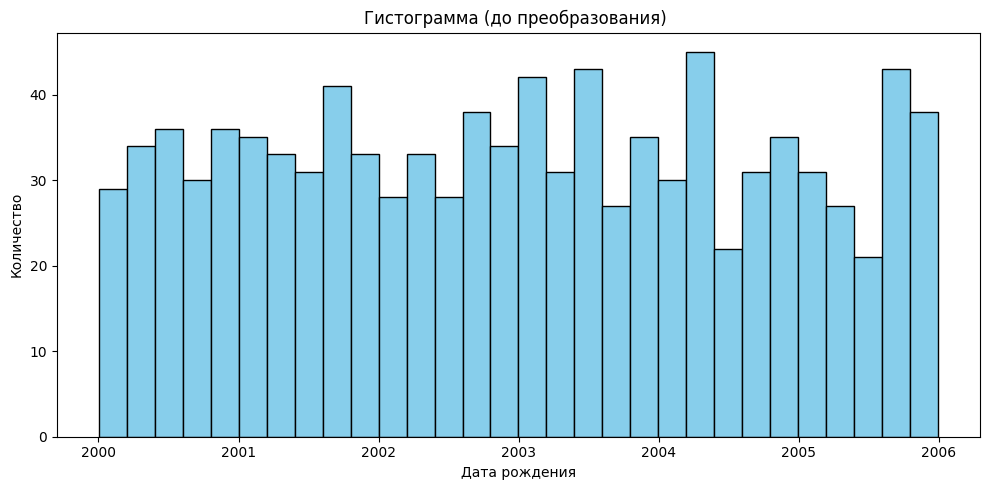

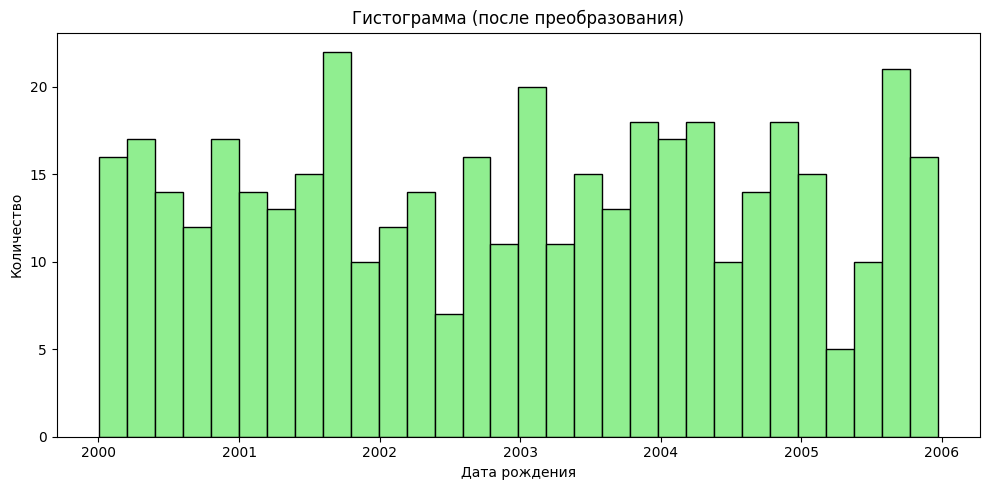

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

np.random.seed(100)
N = 1000

# Примерные списки имён и фамилий
name = ["Александр", "Сергей", "Дмитрий", "Алексей", "Андрей", "Владимир", "Евгений", "Максим", "Иван", "Николай"]
pname = [0.093, 0.070, 0.056, 0.055, 0.050, 0.041, 0.035, 0.032, 0.026, 0.025]
pname = [float(i)/sum(pname) for i in pname]

surname = ["Иванов", "Петров", "Сидоров", "Смирнов", "Кузнецов", "Соколов", "Попов", "Васильев", "Морозов", "Волков"]

fname = ['Елена', 'Наталья', 'Татьяна', 'Ольга', 'Анастасия',
                'Екатерина', 'Ирина', 'Анна', 'Юлия', 'Светлана']
pfname = [0.059, 0.056, 0.051, 0.050, 0.048, 0.045, 0.041, 0.039, 0.038, 0.038]
pfname = [float(i)/sum(pfname) for i in pfname]

fsurname = ['Иванова', 'Петрова', 'Сидорова', 'Смирнова', 'Кузнецова',
                    'Попова', 'Васильева', 'Новикова', 'Федорова', 'Морозова']


cities = ["Москва", "Санкт-Петербург", "Уфа", "Новосибирск", "Екатеринбург", "Самара"]
streets = ["Проспект Октября", "Менделеева", "Ленина", "Гагарина", "Маршала Жукова", "Пушкина"]

start_date = datetime(2000, 1, 1)
end_date = datetime(2005, 12, 31)
days_range = (end_date - start_date).days

#birthdays = [start_date + timedelta(days=np.random.randint(0, days_range)) for i in range(N)]
birthdays = [start_date + timedelta(days=np.round(np.random.uniform(0, days_range))) for i in range(N)]

# Формирование адреса
addresses = []
for i in range(N):
    city = np.random.choice(cities)
    street = np.random.choice(streets)
    house = np.random.randint(1, 10)
    flat = np.random.randint(1, 100)
    address = f"{city}, ул. {street}, д. {house}, кв. {flat}"
    addresses.append((city, street, house, flat, address))

#data = []

names = []
surnames = []

gender = np.random.choice(["Мужской", "Женский"], size=N)
for g in gender:
    if g == "Мужской":
        names.append(np.random.choice(name, p = pname))
        surnames.append(np.random.choice(surname))
    else:
        names.append(np.random.choice(fname, p = pfname))
        surnames.append(np.random.choice(fsurname))

# Собираем всё в DataFrame
df = pd.DataFrame({
    "Имя": names,
    "Фамилия": surnames,
    "Дата рождения": birthdays,
    "Пол": gender,
    "ВУ": np.random.choice([True, False], size=N),
    "Адрес": [a[4] for a in addresses],
    "Город": [a[0] for a in addresses],
    "Улица": [a[1] for a in addresses],
    "Дом": [a[2] for a in addresses],
    "Квартира": [a[3] for a in addresses]
})

# to
df.to_excel("data.xlsx", index=False)

# from
df_loaded = pd.read_excel("data.xlsx")

# Гистограмма
plt.figure(figsize=(10,5))
plt.hist(df_loaded["Дата рождения"], bins=30, color="skyblue", edgecolor="black")
plt.title("Гистограмма (до преобразования) ")
plt.xlabel("Дата рождения")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

# Преобразование: Удалить записи с нечетным номером дома
df_transformed = df_loaded[df_loaded["Дом"] % 2 == 0]

# Перевод в json
df_transformed.to_json("data.json", orient="records", force_ascii=False, indent=4, date_format="iso")

# Загружаем, милисекунды в даты
df_final = pd.read_json("data.json", convert_dates=["Дата рождения"])

# Гистограмма
plt.figure(figsize=(10,5))
plt.hist(df_final["Дата рождения"], bins=30, color="lightgreen", edgecolor="black")
plt.title("Гистограмма (после преобразования)")
plt.xlabel("Дата рождения")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

df_excel = pd.read_excel("data.xlsx")
df_excel.head()

,Имя,Фамилия,Дата рождения,Пол,ВУ,Адрес,Город,Улица,Дом,Квартира
0,Александр,Смирнов,2003-04-06,Мужской,True,"Санкт-Петербург, ул. Ленина, д. 1, кв. 21",Санкт-Петербург,Ленина,1,21
1,Дмитрий,Кузнецов,2001-09-02,Мужской,True,"Москва, ул. Ленина, д. 4, кв. 79",Москва,Ленина,4,79
2,Татьяна,Смирнова,2002-07-19,Женский,False,"Самара, ул. Ленина, д. 3, кв. 39",Самара,Ленина,3,39
3,Светлана,Васильева,2005-01-25,Женский,False,"Самара, ул. Проспект Октября, д. 7, кв. 82",Самара,Проспект Октября,7,82
4,Екатерина,Кузнецова,2000-01-11,Женский,True,"Москва, ул. Ленина, д. 4, кв. 99",Москва,Ленина,4,99


In [11]:
df_json = pd.read_json("data.json", convert_dates=["Дата рождения"])

df_json.head()

,Имя,Фамилия,Дата рождения,Пол,ВУ,Адрес,Город,Улица,Дом,Квартира
0,Дмитрий,Кузнецов,2001-09-02,Мужской,True,"Москва, ул. Ленина, д. 4, кв. 79",Москва,Ленина,4,79
1,Екатерина,Кузнецова,2000-01-11,Женский,True,"Москва, ул. Ленина, д. 4, кв. 99",Москва,Ленина,4,99
2,Александр,Петров,2004-01-10,Мужской,True,"Санкт-Петербург, ул. Ленина, д. 6, кв. 14",Санкт-Петербург,Ленина,6,14
3,Анастасия,Попова,2000-08-25,Женский,False,"Санкт-Петербург, ул. Ленина, д. 6, кв. 10",Санкт-Петербург,Ленина,6,10
4,Алексей,Васильев,2001-01-12,Мужской,False,"Москва, ул. Менделеева, д. 4, кв. 17",Москва,Менделеева,4,17


In [12]:
print(pname)
print(sum(pname))


[0.19254658385093165, 0.14492753623188406, 0.11594202898550723, 0.11387163561076603, 0.10351966873706003, 0.08488612836438923, 0.07246376811594203, 0.06625258799171842, 0.05383022774327122, 0.05175983436853002]
0.9999999999999999
